# Forecast Using the TimesFM Family

foundationforecast ships a single `TimesFM` class that routes to the correct backend from the Hugging Face `repo_id`. Supported PyTorch checkpoints:

| Version | `repo_id` | Parameters | Weights license |
|---------|-----------|------------|-----------------|
| **1.0** | `google/timesfm-1.0-200m-pytorch` | 200M | Apache-2.0 |
| **2.0** | `google/timesfm-2.0-500m-pytorch` | 500M | Apache-2.0 |
| **2.5** | `google/timesfm-2.5-200m-pytorch` | 200M | Apache-2.0 |
| **3.0** | `google/timesfm-3.0-pytorch` | 330M | [Non-commercial](https://huggingface.co/google/timesfm-3.0-pytorch/blob/main/LICENSE) |

In this example we compare all four generations on event pageview data.

**Prediction intervals:** TimesFM outputs nine fixed quantiles (0.1 through 0.9). Pass `level=[0, 20, 40, 60, 80]` to request all supported prediction intervals; custom levels or quantiles are not supported.

## Import libraries

In [21]:
import pandas as pd

from foundationforecast import FoundationForecast

## Load the dataset

The DataFrame must include at least the following columns:
- unique_id: Unique identifier for each time series (string)
- ds: Date column (datetime format)
- y: Target variable for forecasting (float format)

The pandas frequency will be inferred from the ds column, if not provided.
If the seasonality is not provided, it will be inferred based on the frequency.
If the horizon is not set, it will default to 2 times the inferred seasonality.

In [22]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()

,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Plot the data

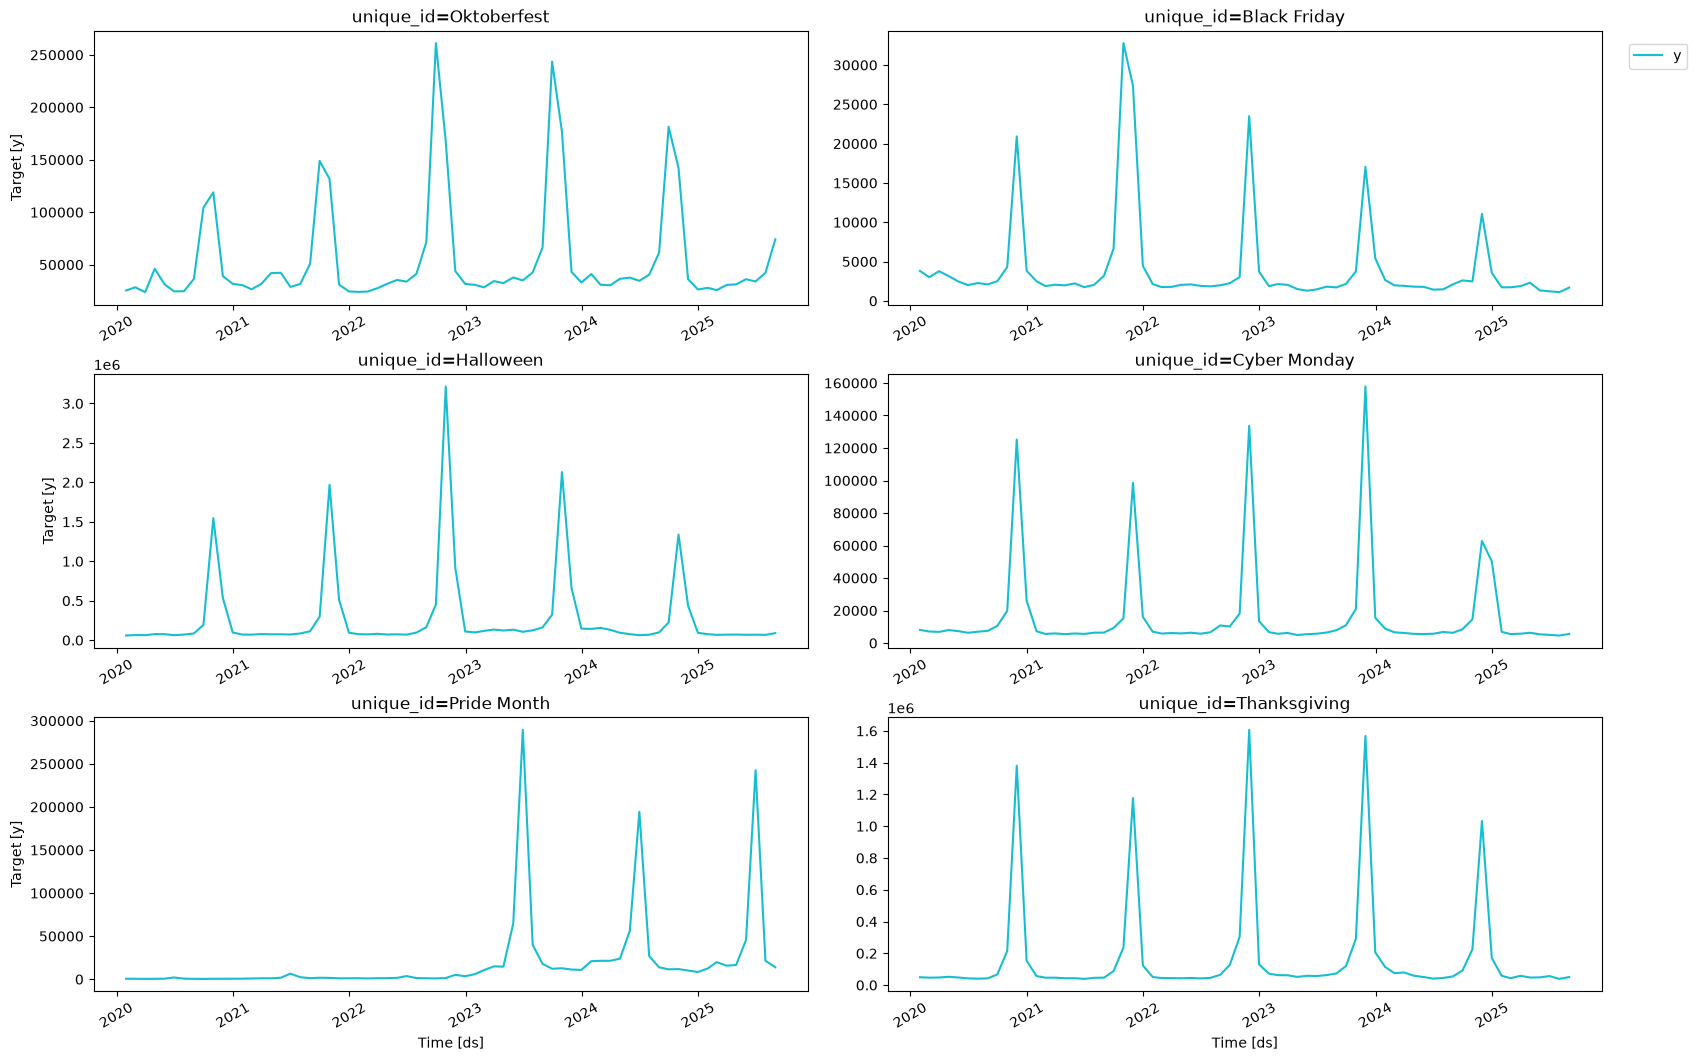

In [23]:
FoundationForecast.plot(df)

## Import the models

In [24]:
from foundationforecast.models.timesfm import TimesFM

## Create a FoundationForecast

We compare TimesFM 1.0, 2.0, 2.5, and 3.0. Each model gets a distinct `alias` so its forecasts are easy to identify.

TimesFM 1.0 supports up to 512 context steps; 2.0 supports up to 2048; 2.5 up to 16384; 3.0 up to 15360. We use `context_length=512` here for a fair comparison and faster runtime.

In [25]:
context_length = 512

models = [
    TimesFM(
        repo_id="google/timesfm-1.0-200m-pytorch",
        alias="TimesFM-1.0",
        context_length=context_length,
    ),
    TimesFM(
        repo_id="google/timesfm-2.0-500m-pytorch",
        alias="TimesFM-2.0",
        context_length=context_length,
    ),
    TimesFM(
        repo_id="google/timesfm-2.5-200m-pytorch",
        alias="TimesFM-2.5",
        context_length=context_length,
    ),
    TimesFM(
        repo_id="google/timesfm-3.0-pytorch",
        alias="TimesFM-3",
        context_length=context_length,
    ),
]

ff = FoundationForecast(models=models)

## Generate forecast

You can optionally specify the following parameters:
- freq: The frequency of your data (e.g., 'D' for daily, 'M' for monthly)
- h: The forecast horizon, which is the number of periods to predict
- seasonality: The seasonal period of your data, which can be inferred if not provided
- level: Prediction interval levels supported by TimesFM (maps to quantiles 0.1–0.9)

In [26]:
level = [0, 20, 40, 60, 80]  # required to use all TimesFM-supported quantiles
cv_df = ff.cross_validation(df=df, h=12, level=level)

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 557.85it/s]
INFO:root:Loading checkpoint from /Users/azul/.cache/huggingface/hub/models--google--timesfm-1.0-200m-pytorch/snapshots/0581e2c56cb06feb51cfd98fc2b4005b74f7187b/torch_model.ckpt
INFO:root:Sending checkpoint to device cpu
INFO:root:Preprocessing dataframe.


Processing dataframe with single process.
Finished preprocessing dataframe.


INFO:root:Finished creating output dataframe.
1it [00:02,  2.44s/it]


Finished forecasting.


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 1176.39it/s]
INFO:root:Loading checkpoint from /Users/azul/.cache/huggingface/hub/models--google--timesfm-2.0-500m-pytorch/snapshots/dc2443792ce5516872b89b37cf1bc058c3bf0c10/torch_model.ckpt
INFO:root:Sending checkpoint to device cpu
INFO:root:Preprocessing dataframe.


Processing dataframe with single process.
Finished preprocessing dataframe.


INFO:root:Finished creating output dataframe.
1it [00:05,  5.90s/it]


Finished forecasting.


0it [00:00, ?it/s]INFO:root:Downloading checkpoint from Hugging Face repo google/timesfm-2.5-200m-pytorch
INFO:root:Loading checkpoint from: /Users/azul/.cache/huggingface/hub/models--google--timesfm-2.5-200m-pytorch/snapshots/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/model.safetensors
INFO:root:When compiling, max horizon needs to be multiple of the output patch size 128. Using max horizon = 128 instead.
100%|██████████| 1/1 [00:00<00:00,  1.35it/s]
1it [00:08,  8.58s/it]
100%|██████████| 1/1 [00:01<00:00,  1.09s/it]
1it [00:04,  4.33s/it]


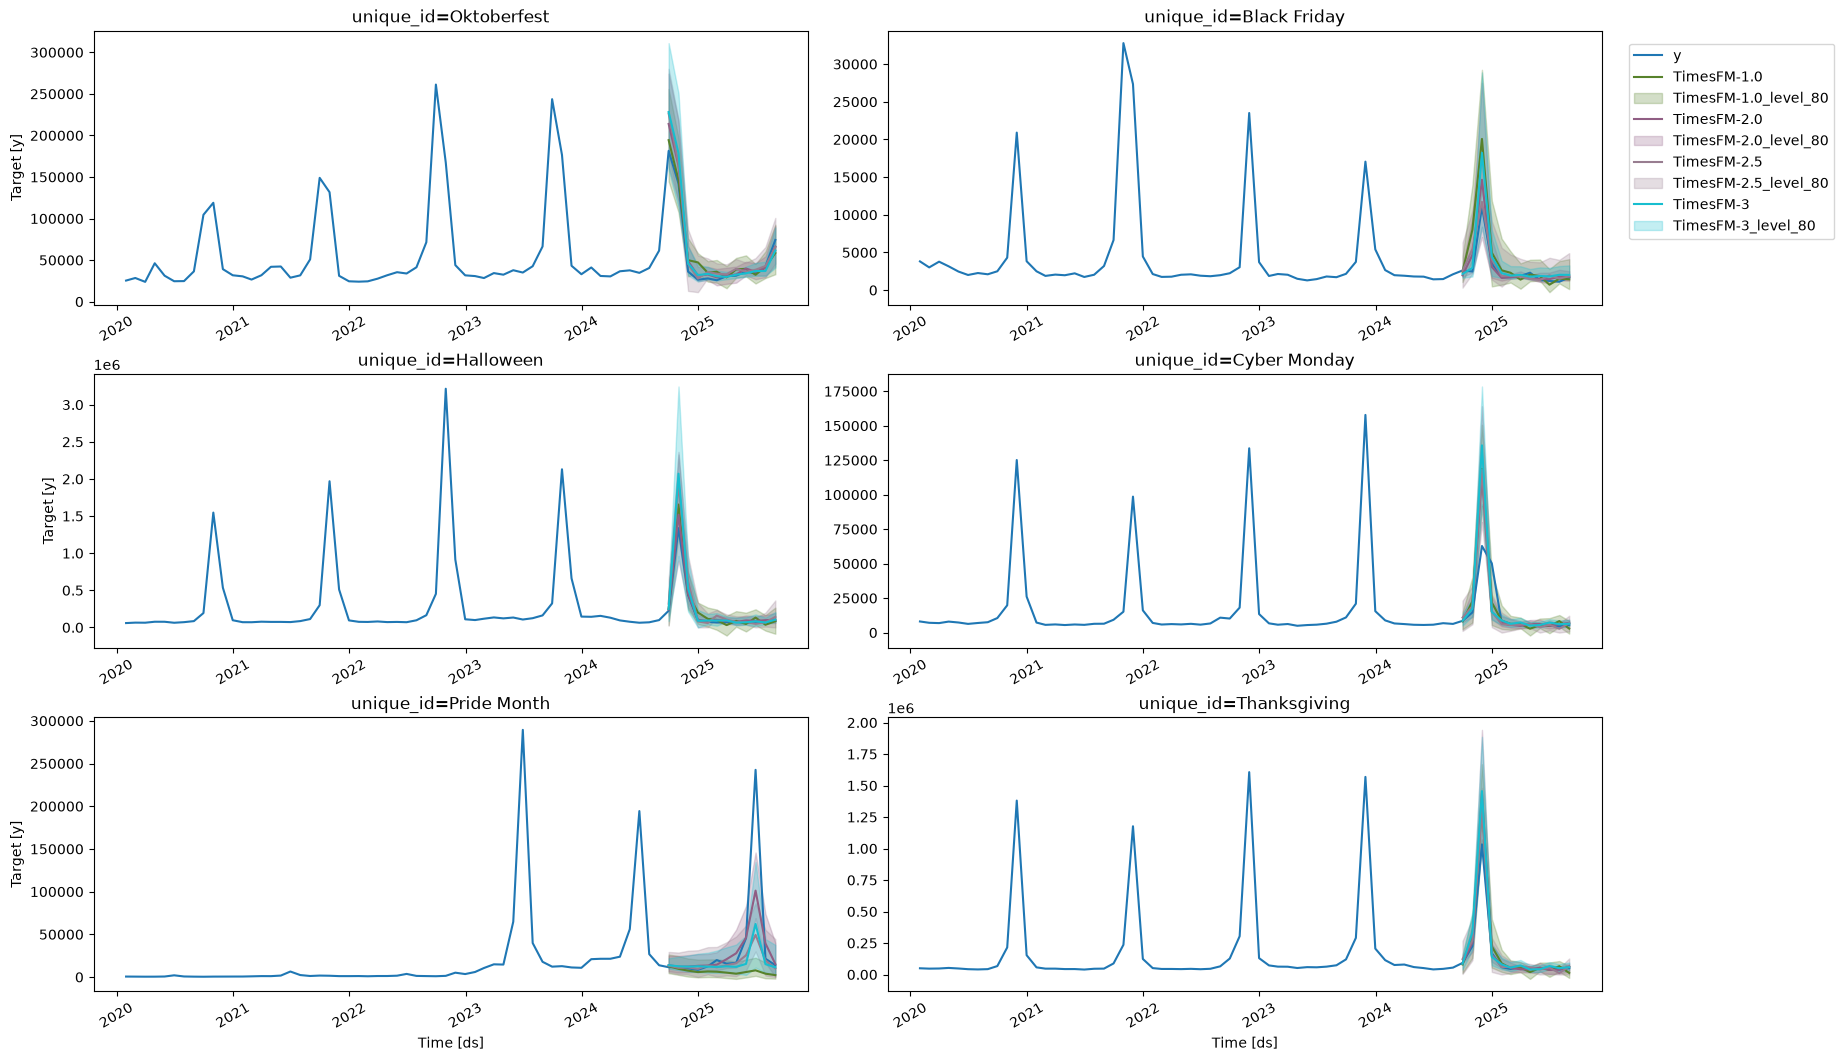

In [27]:
ff.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])

In [28]:
cv_df.head()

,unique_id,ds,cutoff,y,TimesFM-1.0,TimesFM-1.0-lo-0,TimesFM-1.0-hi-0,TimesFM-1.0-lo-20,TimesFM-1.0-hi-20,TimesFM-1.0-lo-40,...,TimesFM-3-lo-0,TimesFM-3-hi-0,TimesFM-3-lo-20,TimesFM-3-hi-20,TimesFM-3-lo-40,TimesFM-3-hi-40,TimesFM-3-lo-60,TimesFM-3-hi-60,TimesFM-3-lo-80,TimesFM-3-hi-80
0,Black Friday,2024-09-30,2024-08-31,2607,2445.430420,2445.430420,2445.430420,2039.546631,2536.117432,1888.667969,...,2138.981934,2138.981934,2045.230347,2256.635986,1912.275269,2419.777344,1803.024902,2602.782715,1650.038818,3203.467285
1,Black Friday,2024-10-31,2024-08-31,2470,8016.879883,8016.879883,8016.879883,6955.782227,8661.800781,6091.328613,...,2950.270996,2950.270996,2717.330566,3199.111328,2516.418457,3526.840820,2241.405762,3984.340576,1803.946655,4985.999512
2,Black Friday,2024-11-30,2024-08-31,11058,20068.869141,20068.869141,20068.869141,18649.710938,21551.666016,17375.398438,...,18230.794922,18230.794922,14493.655273,21952.398438,12077.541016,24506.675781,10137.169922,26544.208984,8425.791992,28899.083984
3,Black Friday,2024-12-31,2024-08-31,3548,4971.047363,4971.047363,4971.047363,3831.354980,5774.150391,3115.749512,...,4424.556152,4424.556152,3700.198242,5144.618652,3103.180664,5830.979004,2568.543457,6557.108398,1861.944946,7998.727539
4,Black Friday,2025-01-31,2024-08-31,1724,2627.586182,2627.586182,2627.586182,2249.988037,3079.314209,1964.180176,...,2250.440430,2250.440430,2133.444336,2394.948242,1964.228271,2652.994629,1812.288330,3007.504883,1601.604004,3891.986328


## Evaluation

In [29]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

In [30]:
eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.sort_values(
    by="scaled_crps"
).round(3)

metric,mase,scaled_crps
TimesFM-2.0,1.086,0.260
TimesFM-3,1.448,0.333
TimesFM-2.5,1.233,0.335
TimesFM-1.0,1.422,0.394
